# Visualisasi UHI Jakarta — NDVI, NDBI, dan LST
Notebook ini membuat **line chart** (tren rata-rata per tahun) dan **box plot** (sebaran nilai per tahun)
untuk dua dataset:

1. `FINAL_NDVI_NDBI_Grid1km_Jakarta_ALL_YEARS.geojson` → kolom `NDVI`, `NDBI`, `year`, `sensor`
2. `LSTPuncakKemarau.geojson` → kolom `mean` (LST), `period`

Path data disesuaikan dengan lokasi di komputer kamu:
`C:\Users\Solideo G. Bangun\uhi-dashboard\data`


## 1. Import Library

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


## 2. Load Data
Sesuaikan `DATA_DIR` jika lokasi folder berbeda.

In [2]:
DATA_DIR = r"C:\Users\Solideo G. Bangun\uhi-dashboard\data"

ndvi_ndbi_path = DATA_DIR + r"\FINAL_NDVI_NDBI_Grid1km_Jakarta_ALL_YEARS.geojson"
lst_path       = DATA_DIR + r"\LSTPuncakKemarau.geojson"

gdf_ndvi_ndbi = gpd.read_file(ndvi_ndbi_path)
gdf_lst       = gpd.read_file(lst_path)

print("NDVI/NDBI:", gdf_ndvi_ndbi.shape)
print("LST       :", gdf_lst.shape)

gdf_ndvi_ndbi.head()


NDVI/NDBI: (3864, 8)
LST       : (3864, 8)


,id,NDBI,NDVI,count,grid_id,sensor,year,geometry
0,0_+687+9317,-0.040687,0.326384,4,93175000687,landsat7,2009,"POLYGON ((106.69 -6.16735, 106.69003 -6.17639,..."
1,0_+687+9318,0.011025,0.270527,4,93185000687,landsat7,2009,"POLYGON ((106.68997 -6.15831, 106.69 -6.16735,..."
2,0_+687+9319,0.021709,0.245765,4,93195000687,landsat7,2009,"POLYGON ((106.68994 -6.14926, 106.68997 -6.158..."
3,0_+687+9320,0.002569,0.254019,4,93205000687,landsat7,2009,"POLYGON ((106.68991 -6.14022, 106.68994 -6.149..."
4,0_+687+9321,-0.006131,0.251864,4,93215000687,landsat7,2009,"POLYGON ((106.68988 -6.13118, 106.68991 -6.140..."


In [3]:
gdf_lst.head()


,id,end_month,first,grid_id,mean,period,start_month,geometry
0,0_+687+9317,8,1,93175000687,37.232520,2009,8,"POLYGON ((106.69 -6.16735, 106.69003 -6.17639,..."
1,0_+687+9318,8,1,93185000687,37.607294,2009,8,"POLYGON ((106.68997 -6.15831, 106.69 -6.16735,..."
2,0_+687+9319,8,1,93195000687,37.599023,2009,8,"POLYGON ((106.68994 -6.14926, 106.68997 -6.158..."
3,0_+687+9320,8,1,93205000687,37.118608,2009,8,"POLYGON ((106.68991 -6.14022, 106.68994 -6.149..."
4,0_+687+9321,8,1,93215000687,36.461000,2009,8,"POLYGON ((106.68988 -6.13118, 106.68991 -6.140..."


## 3. Persiapan Data

- `year` pada dataset NDVI/NDBI diubah menjadi tipe integer agar urut dengan benar.
- `period` pada dataset LST sudah berbentuk tahun (int).


In [4]:
df_ndvi_ndbi = gdf_ndvi_ndbi.drop(columns="geometry").copy()
df_ndvi_ndbi["year"] = df_ndvi_ndbi["year"].astype(int)

df_lst = gdf_lst.drop(columns="geometry").copy()
df_lst["period"] = df_lst["period"].astype(int)

df_ndvi_ndbi.sort_values("year").head()


,id,NDBI,NDVI,count,grid_id,sensor,year
0,0_+687+9317,-0.040687,0.326384,4,93175000687,landsat7,2009
425,0_+707+9319,0.041579,0.091187,4,93195000707,landsat7,2009
426,0_+707+9320,0.019347,0.056724,3,93205000707,landsat7,2009
427,0_+707+9321,0.029858,0.061891,3,93215000707,landsat7,2009
428,0_+707+9322,0.040499,0.062747,3,93225000707,landsat7,2009


---
## 4. NDVI & NDBI — Line Chart (Rata-rata per Tahun)

In [5]:
agg_ndvi_ndbi = (
    df_ndvi_ndbi.groupby("year")[["NDVI", "NDBI"]]
    .mean()
    .reset_index()
    .sort_values("year")
)
agg_ndvi_ndbi


,year,NDVI,NDBI
0,2009,0.233296,-0.006619
1,2012,0.221656,0.000559
2,2015,0.292246,0.000996
3,2018,0.299840,0.000052
4,2021,0.240409,0.058551
5,2024,0.244754,0.057892


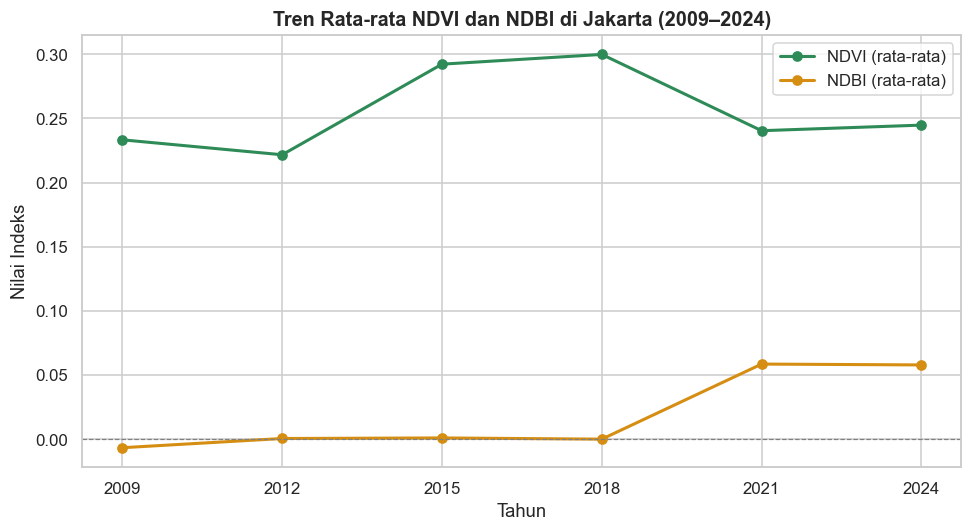

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(agg_ndvi_ndbi["year"], agg_ndvi_ndbi["NDVI"],
        marker="o", linewidth=2, label="NDVI (rata-rata)", color="#2E8B57")
ax.plot(agg_ndvi_ndbi["year"], agg_ndvi_ndbi["NDBI"],
        marker="o", linewidth=2, label="NDBI (rata-rata)", color="#D58E12")

ax.set_title("Tren Rata-rata NDVI dan NDBI di Jakarta (2009–2024)", fontsize=13, fontweight="bold")
ax.set_xlabel("Tahun")
ax.set_ylabel("Nilai Indeks")
ax.set_xticks(agg_ndvi_ndbi["year"])
ax.legend()
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig(DATA_DIR + r"\line_ndvi_ndbi.png", dpi=150)
plt.show()


## 5. NDVI & NDBI — Box Plot (Sebaran Nilai per Tahun)

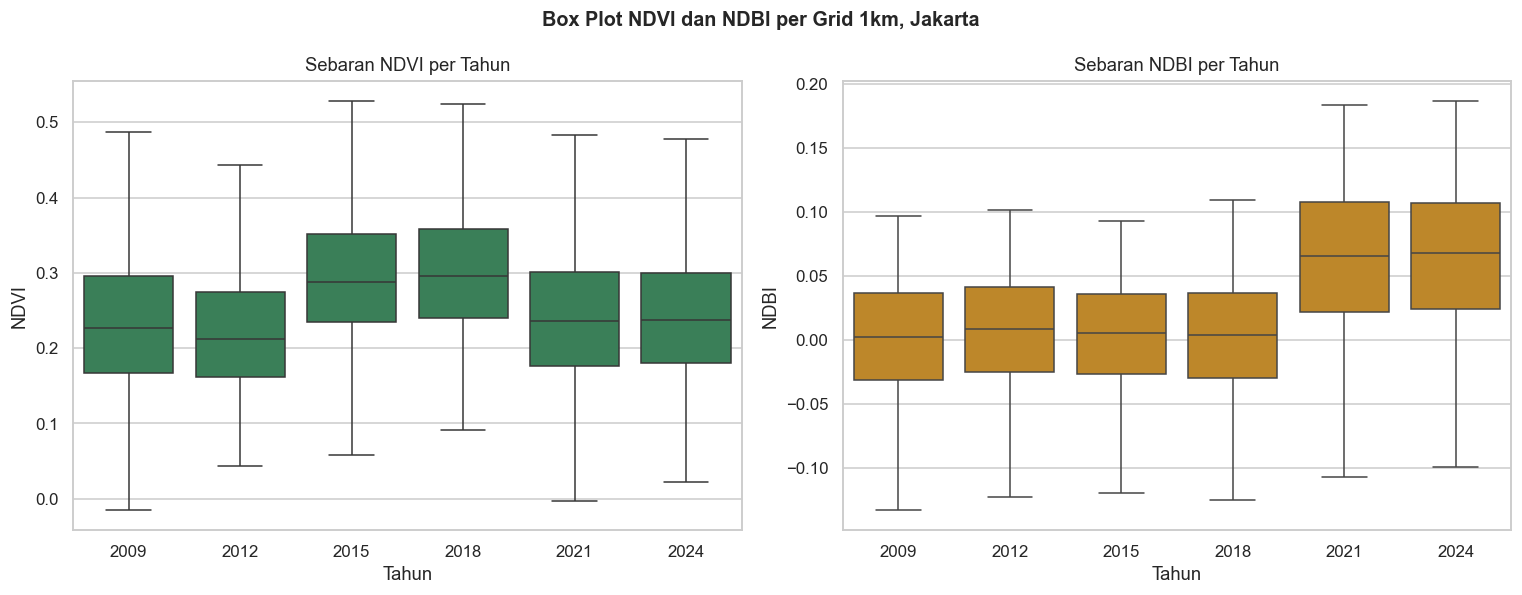

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)

sns.boxplot(data=df_ndvi_ndbi, x="year", y="NDVI", ax=axes[0],
            color="#2E8B57", showfliers=False)
axes[0].set_title("Sebaran NDVI per Tahun")
axes[0].set_xlabel("Tahun")
axes[0].set_ylabel("NDVI")

sns.boxplot(data=df_ndvi_ndbi, x="year", y="NDBI", ax=axes[1],
            color="#D58E12", showfliers=False)
axes[1].set_title("Sebaran NDBI per Tahun")
axes[1].set_xlabel("Tahun")
axes[1].set_ylabel("NDBI")

plt.suptitle("Box Plot NDVI dan NDBI per Grid 1km, Jakarta", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR + r"\boxplot_ndvi_ndbi.png", dpi=150)
plt.show()


---
## 6. LST (Land Surface Temperature) — Line Chart (Rata-rata per Periode)

In [8]:
agg_lst = (
    df_lst.groupby("period")["mean"]
    .mean()
    .reset_index()
    .sort_values("period")
)
agg_lst


,period,mean
0,2009,37.306487
1,2012,36.950242
2,2015,38.070692
3,2018,38.365558
4,2021,37.159705
5,2024,34.962393


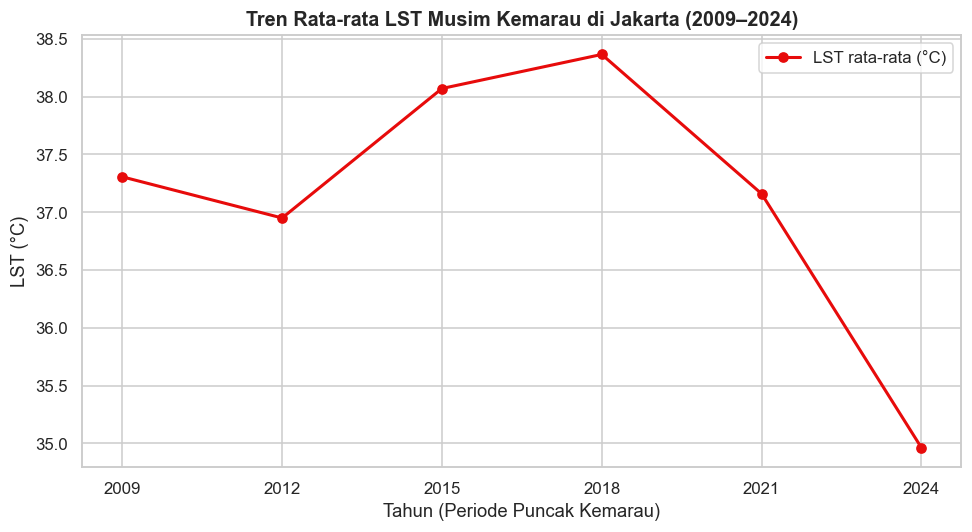

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(agg_lst["period"], agg_lst["mean"],
        marker="o", linewidth=2, color="#E70B0B", label="LST rata-rata (°C)")

ax.set_title("Tren Rata-rata LST Musim Kemarau di Jakarta (2009–2024)", fontsize=13, fontweight="bold")
ax.set_xlabel("Tahun (Periode Puncak Kemarau)")
ax.set_ylabel("LST (°C)")
ax.set_xticks(agg_lst["period"])
ax.legend()

plt.tight_layout()
plt.savefig(DATA_DIR + r"\line_lst.png", dpi=150)
plt.show()


## 7. LST — Box Plot (Sebaran Nilai per Periode)

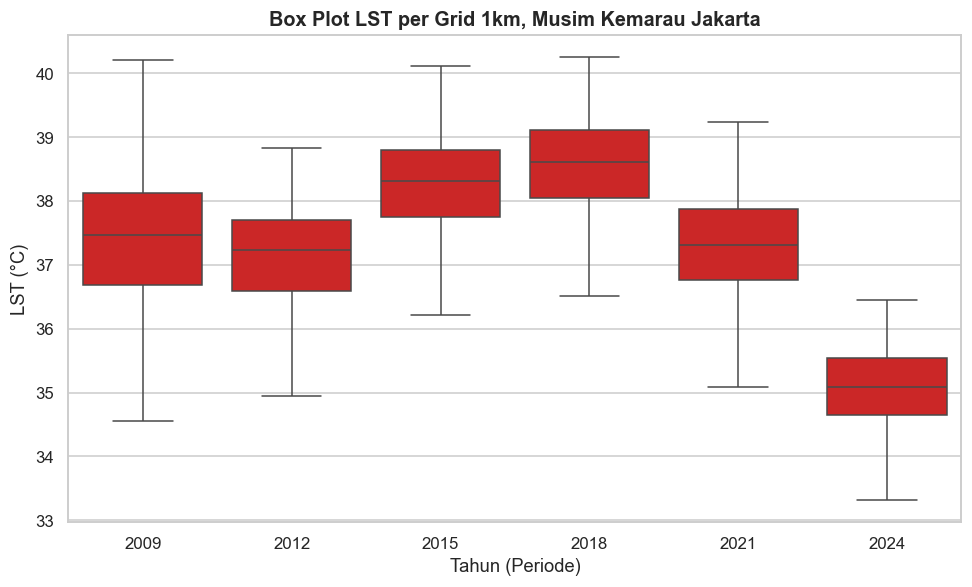

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.boxplot(data=df_lst, x="period", y="mean", ax=ax,
            color="#E70B0B", showfliers=False)

ax.set_title("Box Plot LST per Grid 1km, Musim Kemarau Jakarta", fontsize=13, fontweight="bold")
ax.set_xlabel("Tahun (Periode)")
ax.set_ylabel("LST (°C)")

plt.tight_layout()
plt.savefig(DATA_DIR + r"\boxplot_lst.png", dpi=150)
plt.show()


---
## 8. (Opsional) Gabungan NDVI, NDBI, dan LST dalam satu Line Chart
Menggabungkan ketiga tren dengan dua sumbu-y karena skala LST berbeda jauh dari NDVI/NDBI.

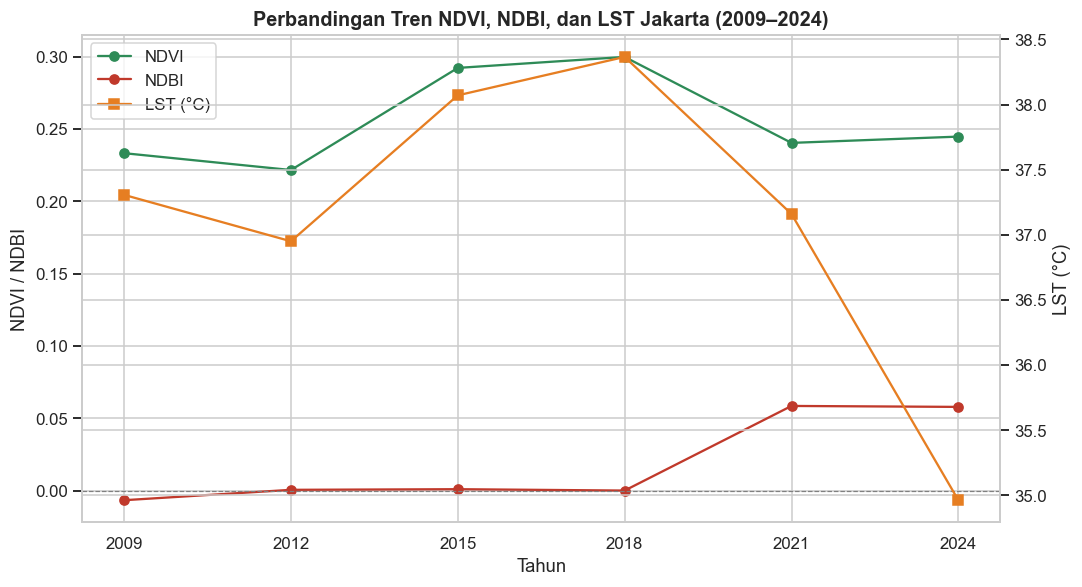

In [11]:
merged = agg_ndvi_ndbi.merge(agg_lst, left_on="year", right_on="period")

fig, ax1 = plt.subplots(figsize=(10, 5.5))

ax1.plot(merged["year"], merged["NDVI"], marker="o", color="#2E8B57", label="NDVI")
ax1.plot(merged["year"], merged["NDBI"], marker="o", color="#C0392B", label="NDBI")
ax1.set_xlabel("Tahun")
ax1.set_ylabel("NDVI / NDBI")
ax1.set_xticks(merged["year"])
ax1.axhline(0, color="grey", linewidth=0.8, linestyle="--")

ax2 = ax1.twinx()
ax2.plot(merged["year"], merged["mean"], marker="s", color="#E67E22", label="LST (°C)")
ax2.set_ylabel("LST (°C)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Perbandingan Tren NDVI, NDBI, dan LST Jakarta (2009–2024)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR + r"\line_gabungan.png", dpi=150)
plt.show()


C:\Users\Solideo G. Bangun\AppData\Local\Temp\ipykernel_18784\3041775666.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.97])


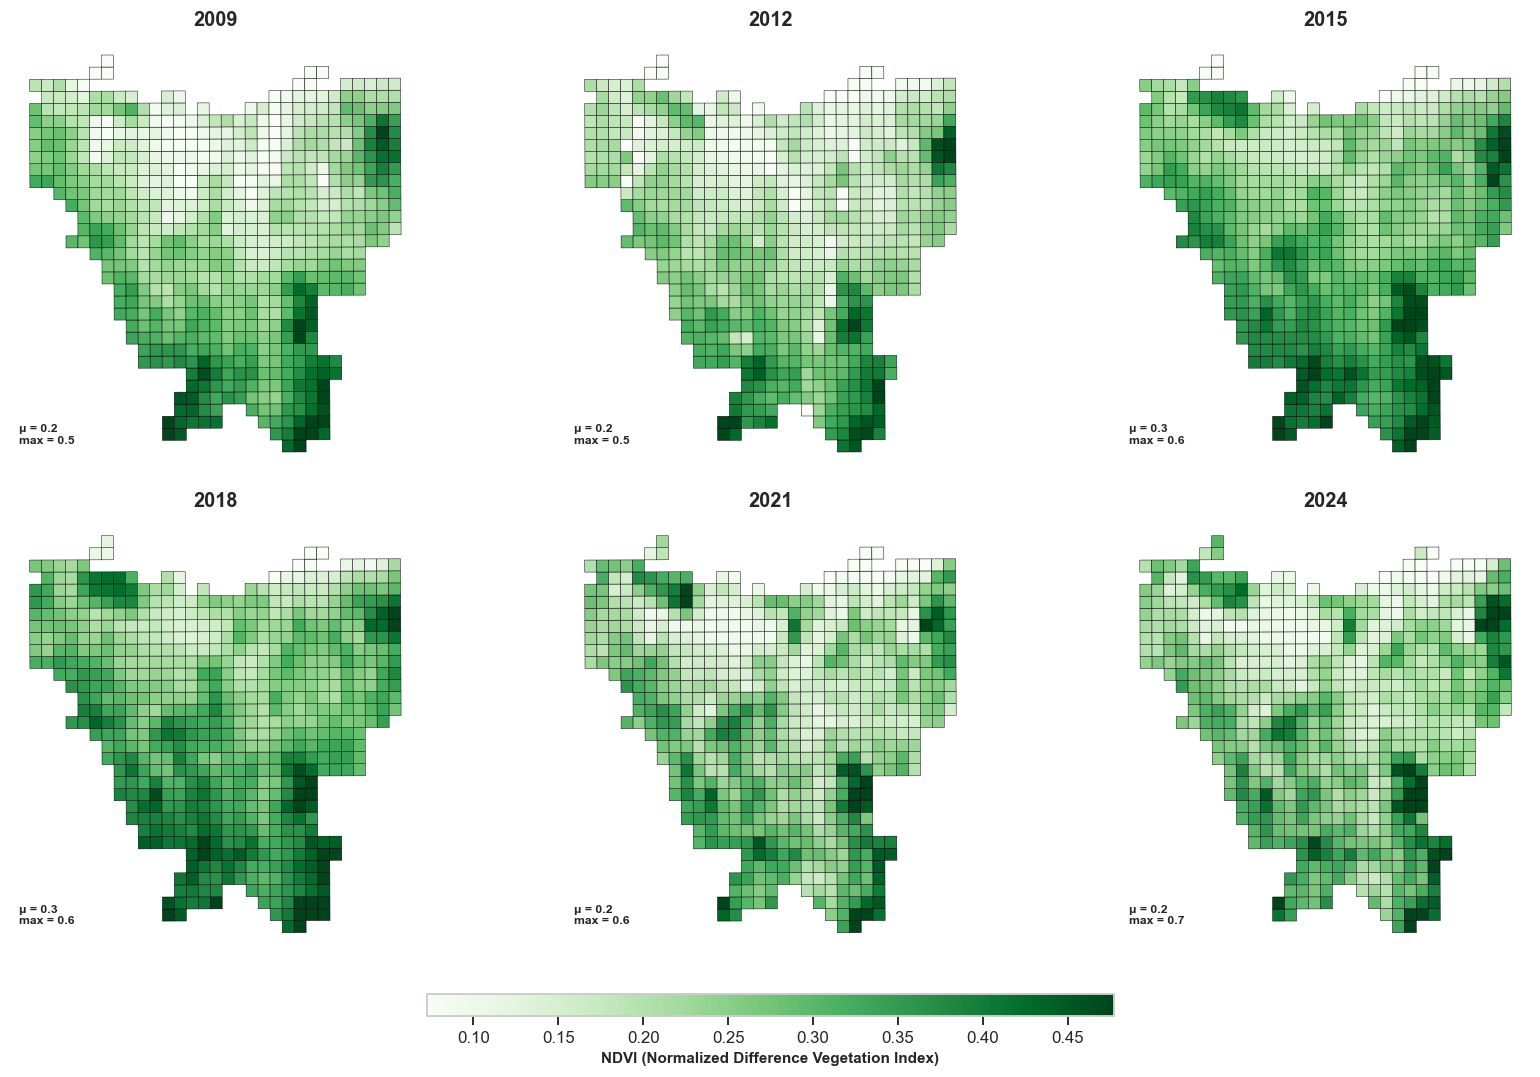

C:\Users\Solideo G. Bangun\AppData\Local\Temp\ipykernel_18784\3041775666.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.97])


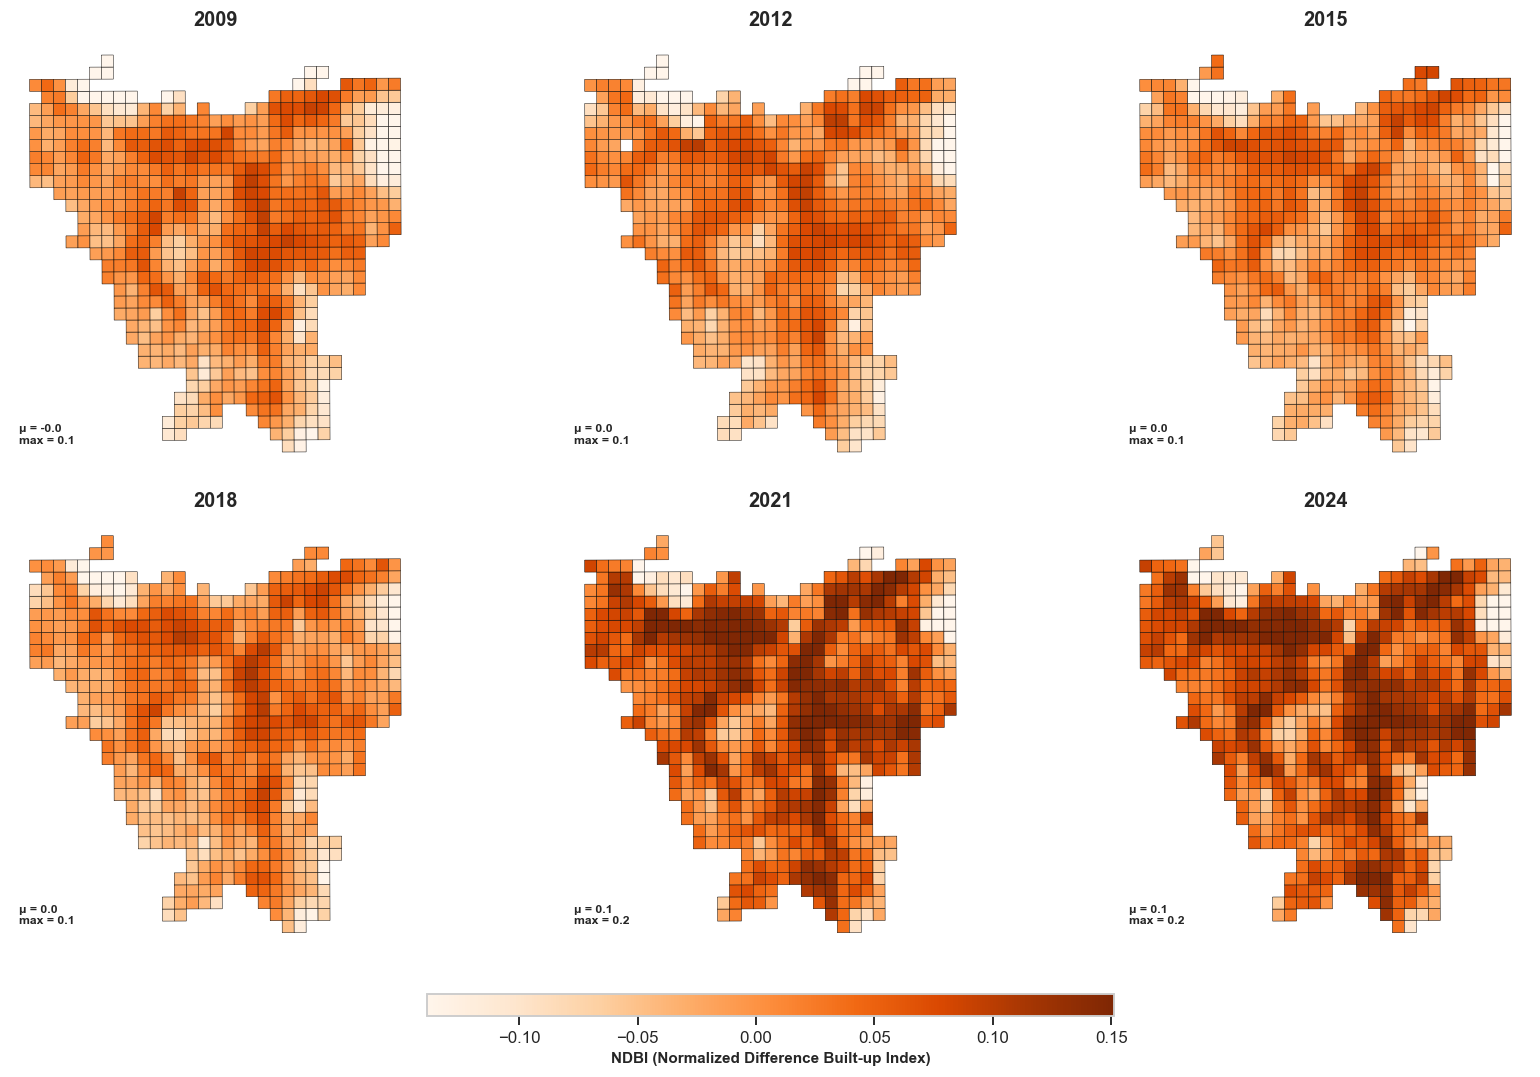

C:\Users\Solideo G. Bangun\AppData\Local\Temp\ipykernel_18784\3041775666.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.97])


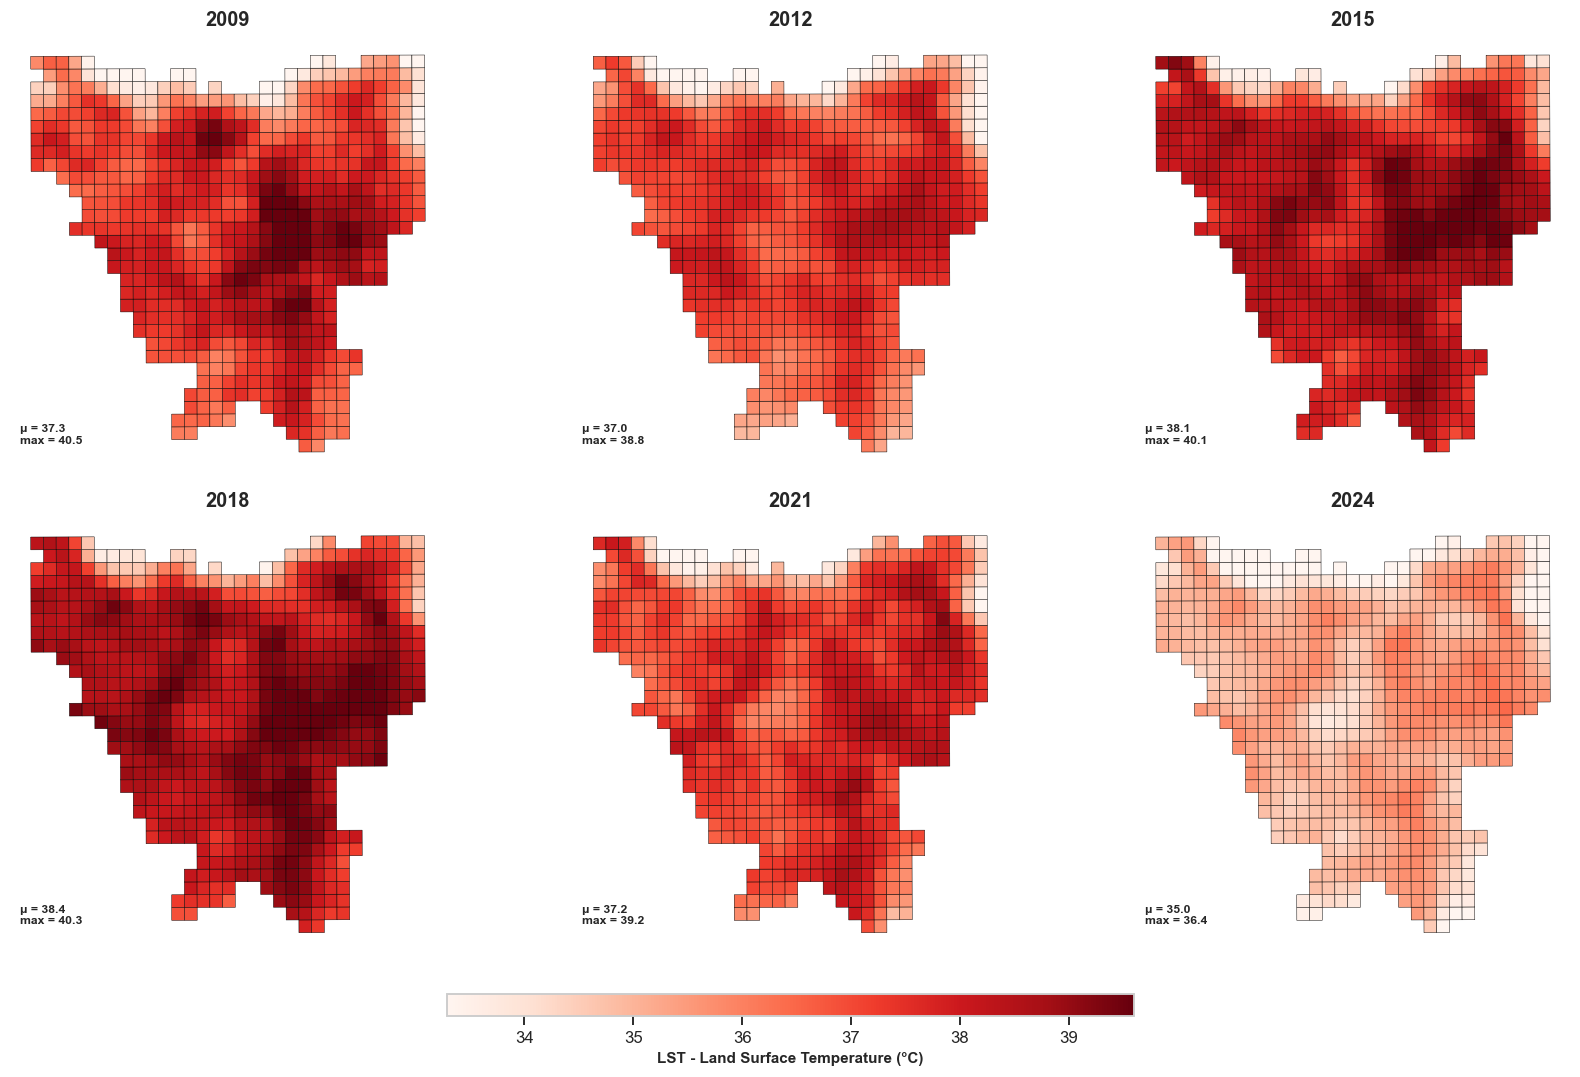

In [19]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np


def plot_year_grid_maps(
    gdf,
    value_col,
    year_col,
    cmap,
    legend_label,
    title,
    filename,
    vmin=None,
    vmax=None,
    reverse_stats=False,
):
    """Membuat small-multiple choropleth map per tahun (grid 2 baris x 3 kolom),

    lengkap dengan anotasi mu (mean) & max, dan colorbar horizontal di bawah.
    """
    years = sorted(gdf[year_col].unique())
    n = len(years)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    if vmin is None:
        vmin = gdf[value_col].quantile(0.02)
    if vmax is None:
        vmax = gdf[value_col].quantile(0.98)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, yr in enumerate(years):
        ax = axes[i]
        sub = gdf[gdf[year_col] == yr]

        sub.plot(
            column=value_col,
            cmap=cmap,
            linewidth=0.3,
            edgecolor="black",
            ax=ax,
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(str(yr), fontsize=13, fontweight="bold")
        ax.set_axis_off()

        mu = sub[value_col].mean()
        mx = sub[value_col].max()
        ax.text(
            0.02,
            0.06,
            f"\u03bc = {mu:.1f}\nmax = {mx:.1f}",
            transform=ax.transAxes,
            fontsize=8,
            fontweight="bold",
            va="bottom",
            ha="left",
        )

    # kosongkan subplot sisa (jika jumlah tahun ganjil)
    for j in range(n, len(axes)):
        axes[j].set_axis_off()

    fig.suptitle(title, fontsize=15, fontweight="bold", y=0.995)

    # colorbar horizontal di bawah
    sm = plt.cm.ScalarMappable(
        cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax)
    )
    sm._A = []
    cbar_ax = fig.add_axes([0.3, 0.02, 0.4, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(legend_label, fontsize=10, fontweight="bold")

    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.savefig(DATA_DIR + filename, dpi=150, bbox_inches="tight")
    plt.show()


# 1) Peta NDVI per tahun (warna dasar hijau)
plot_year_grid_maps(
    gdf_ndvi_ndbi,
    value_col="NDVI",
    year_col="year",
    cmap="Greens",  # Gradasi Hijau (Bisa juga gunakan 'YlGn')
    legend_label="NDVI (Normalized Difference Vegetation Index)",
    title="",
    filename=r"\map_ndvi_per_year.png",
)

# 2) Peta NDBI per tahun (warna dasar oranye)
plot_year_grid_maps(
    gdf_ndvi_ndbi,
    value_col="NDBI",
    year_col="year",
    cmap="Oranges",  # Gradasi Oranye (Bisa juga gunakan 'YlOrBr')
    legend_label="NDBI (Normalized Difference Built-up Index)",
    title="",
    filename=r"\map_ndbi_per_year.png",
)

# 3) Peta LST per tahun (warna dasar merah)
plot_year_grid_maps(
    gdf_lst,
    value_col="mean",
    year_col="period",
    cmap="Reds",  # Gradasi Merah (Bisa juga gunakan 'YlOrRd')
    legend_label="LST - Land Surface Temperature (\u00b0C)",
    title="",
    filename=r"\map_lst_per_year.png",
)

In [20]:
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# ============================================================
# 1. STATISTIK DESKRIPTIF PER TAHUN — NDVI & NDBI
# ============================================================
desc_ndvi = df_ndvi_ndbi.groupby("year")["NDVI"].describe()[
    ["mean", "std", "min", "50%", "max"]
].rename(columns={"50%": "median"})

desc_ndbi = df_ndvi_ndbi.groupby("year")["NDBI"].describe()[
    ["mean", "std", "min", "50%", "max"]
].rename(columns={"50%": "median"})

print("=== Statistik Deskriptif NDVI per Tahun ===")
display(desc_ndvi)

print("\n=== Statistik Deskriptif NDBI per Tahun ===")
display(desc_ndbi)

# ============================================================
# 2. STATISTIK DESKRIPTIF PER PERIODE — LST
# ============================================================
desc_lst = df_lst.groupby("period")["mean"].describe()[
    ["mean", "std", "min", "50%", "max"]
].rename(columns={"mean": "mean_of_mean", "50%": "median"})

print("\n=== Statistik Deskriptif LST per Tahun (°C) ===")
display(desc_lst)

# ============================================================
# 3. RINGKASAN KESELURUHAN (SEMUA TAHUN DIGABUNG)
# ============================================================
summary_all = pd.DataFrame({
    "NDVI": df_ndvi_ndbi["NDVI"].describe(),
    "NDBI": df_ndvi_ndbi["NDBI"].describe(),
    "LST (°C)": df_lst["mean"].describe(),
})
print("\n=== Ringkasan Statistik Keseluruhan (2009–2024) ===")
display(summary_all)

# ============================================================
# 4. PERUBAHAN ANTAR TAHUN (delta & % perubahan)
# ============================================================
def hitung_perubahan(agg_df, value_col, label):
    tmp = agg_df.copy()
    tmp["delta"] = tmp[value_col].diff()
    tmp["pct_change"] = tmp[value_col].pct_change() * 100
    print(f"\n=== Perubahan {label} Antar Tahun ===")
    display(tmp)
    total_change = tmp[value_col].iloc[-1] - tmp[value_col].iloc[0]
    pct_total = (total_change / tmp[value_col].iloc[0]) * 100
    print(f"Perubahan total {label} ({tmp.iloc[0,0]}→{tmp.iloc[-1,0]}): "
          f"{total_change:+.4f} ({pct_total:+.1f}%)")
    return tmp

chg_ndvi = hitung_perubahan(agg_ndvi_ndbi[["year", "NDVI"]], "NDVI", "NDVI")
chg_ndbi = hitung_perubahan(agg_ndvi_ndbi[["year", "NDBI"]], "NDBI", "NDBI")
chg_lst  = hitung_perubahan(agg_lst[["period", "mean"]], "mean", "LST")

# ============================================================
# 5. KORELASI ANTAR VARIABEL (NDVI, NDBI, LST) PER GRID & TAHUN
# ============================================================
merged_full = df_ndvi_ndbi.merge(
    df_lst[["grid_id", "period", "mean"]],
    left_on=["grid_id", "year"], right_on=["grid_id", "period"],
    how="inner"
).rename(columns={"mean": "LST"})

corr_matrix = merged_full[["NDVI", "NDBI", "LST"]].corr()
print("\n=== Matriks Korelasi (NDVI vs NDBI vs LST) ===")
display(corr_matrix)

# Korelasi per tahun (opsional, untuk melihat konsistensi hubungan)
corr_per_year = (
    merged_full.groupby("year")
    .apply(lambda d: pd.Series({
        "corr_NDVI_LST": d["NDVI"].corr(d["LST"]),
        "corr_NDBI_LST": d["NDBI"].corr(d["LST"]),
        "corr_NDVI_NDBI": d["NDVI"].corr(d["NDBI"]),
    }))
    .reset_index()
)
print("\n=== Korelasi per Tahun ===")
display(corr_per_year)

# ============================================================
# 6. IDENTIFIKASI GRID EKSTREM (opsional — untuk narasi hotspot)
# ============================================================
tahun_terakhir = df_ndvi_ndbi["year"].max()
data_terakhir = merged_full[merged_full["year"] == tahun_terakhir]

top5_ndvi_rendah = data_terakhir.nsmallest(5, "NDVI")[["grid_id", "NDVI", "NDBI", "LST"]]
top5_lst_tinggi  = data_terakhir.nlargest(5, "LST")[["grid_id", "NDVI", "NDBI", "LST"]]

print(f"\n=== 5 Grid dengan NDVI Terendah ({tahun_terakhir}) — indikasi lahan terbangun/minim vegetasi ===")
display(top5_ndvi_rendah)

print(f"\n=== 5 Grid dengan LST Tertinggi ({tahun_terakhir}) — indikasi hotspot Urban Heat Island ===")
display(top5_lst_tinggi)

=== Statistik Deskriptif NDVI per Tahun ===


,mean,std,min,median,max
year,,,,,
2009,0.2333,0.1075,-0.2184,0.2273,0.5458
2012,0.2217,0.0963,-0.1886,0.2117,0.5206
2015,0.2922,0.0932,-0.2878,0.2878,0.5911
2018,0.2998,0.0879,0.0270,0.2964,0.5562
2021,0.2404,0.0955,-0.1406,0.2358,0.6043
2024,0.2448,0.0971,-0.0789,0.2374,0.6555



=== Statistik Deskriptif NDBI per Tahun ===


,mean,std,min,median,max
year,,,,,
2009,-0.0066,0.0688,-0.4873,0.0021,0.0965
2012,0.0006,0.0629,-0.4025,0.0083,0.1015
2015,0.0010,0.0488,-0.1870,0.0051,0.0926
2018,0.0001,0.0517,-0.2312,0.0037,0.1096
2021,0.0586,0.0681,-0.2360,0.0655,0.1831
2024,0.0579,0.0710,-0.2942,0.0680,0.1866



=== Statistik Deskriptif LST per Tahun (°C) ===


...

,year,corr_NDVI_LST,corr_NDBI_LST,corr_NDVI_NDBI
0,2009,-0.0119,0.5750,-0.2404
1,2012,-0.2292,0.6526,-0.3306
2,2015,-0.0343,0.4534,-0.7627
3,2018,-0.0759,0.5611,-0.7400
4,2021,-0.2465,0.6111,-0.6936
5,2024,-0.3378,0.7139,-0.7274



=== 5 Grid dengan NDVI Terendah (2024) — indikasi lahan terbangun/minim vegetasi ===


,grid_id,NDVI,NDBI,LST
3741,93255000710,-0.0789,-0.0473,33.4882
3822,93255000714,-0.0762,-0.0068,34.7389
3711,93255000709,-0.0629,-0.0377,32.5454
3804,93255000713,-0.0260,0.0341,34.5741
3767,93265000711,0.0223,-0.0028,NaN



=== 5 Grid dengan LST Tertinggi (2024) — indikasi hotspot Urban Heat Island ===


,grid_id,NDVI,NDBI,LST
3809,93125000714,0.1757,0.1796,36.4445
3777,93155000712,0.1965,0.0742,36.3547
3792,93135000713,0.2411,0.1160,36.3476
3816,93195000714,0.1105,0.0969,36.2955
3793,93145000713,0.2845,0.0676,36.2926
